# 1. Answer the questions from the introduction

### 1.1 What is leave-one-out? Provide limitations and strengths.

Leave-One-Out (LOOCV): Частный случай, когда K = n (число объектов в выборке). Каждый объект по очереди становится validation set. <br>
Очень затратно вычисляется, но полезно для очень маленьких датасетов.

### 1.2 How do Grid Search, Randomized Grid Search, and Bayesian optimization work?

#### Grid Search (Поиск по сетке)

Полный перебор всех возможных комбинаций гиперпараметров из заранее заданной сетки.

Плюсы:
- Полностью исчерпывающий - найдет лучшую комбинацию в заданной сетке
- Простой в реализации и понимании
- Детерминированный - всегда дает одинаковый результат

Минусы:
- Вычислительно дорогой - O(Nᴷ) где K - количество параметров
- Неэффективное использование ресурсов - проверяет заведомо плохие комбинации

Когда использовать:
-Малое количество гиперпараметров (1-3)
- Когда вы примерно знаете хорошие диапазоны значений
- Когда вычислительные ресурсы не ограничены


#### Randomized Grid Search (Случайный поиск)

Случайная выборка комбинаций из пространства параметров.

Плюсы:
- Эффективнее Grid Search - проверяет меньше комбинаций
- Исследует большее пространство параметров
- Может найти неочевидные комбинации

Минусы:
- Не гарантирует нахождение глобального оптимума
- Может пропустить хорошие комбинации

Когда использовать:
- Когда пространство параметров большое
- Когда нужно быстро найти хорошее решение

#### Bayesian Optimization (Байесовская оптимизация)

Строит вероятностную модель функции цели и использует ее для выбора перспективных точек.

Плюсы:
- Самый эффективный - требует меньше итераций
- Интеллектуальный поиск - учится на предыдущих результатах
- Хорошо работает в многомерныч пространствах

Минусы:
- Сложнее в реализации
- Требует настройки surrogate model

Когда использовать:
- Когда оценка модели дорогая (глубокое обучение)
- Для сложных пространств параметров
- Когда нужно максимальное качество при ограниченных ресурсах

### 1.3 Explain classification of feature selection methods.<br> Explain how Pearson and Chi2 work. Explain how Lasso works. <br> Explain what permutation significance is. Become familiar with SHAP.

#### Filter Methods (Фильтры)
Оценивают признаки независимо от модели на основе статистических показателей.

- Примеры: Pearson correlation, Chi-square, Mutual Information
- Плюсы: Быстрые, не зависят от модели
- Минусы: Игнорируют взаимодействие признаков

#### Wrapper Methods (Обертки)
Ищут оптимальное подмножество признаков, используя производительность модели как критерий.

- Примеры: Forward Selection, Backward Elimination, Recursive Feature Elimination
- Плюсы: Учитывают взаимодействие признаков
- Минусы: Медленные, риск переобучения

#### Embedded Methods (Встроенные)
Отбор происходит в процессе обучения модели.

- Примеры: Lasso, Decision Trees, Random Forest importance
- Плюсы: Баланс скорости и эффективности
- Минусы: Привязаны к конкретной модели


#### Pearson
В статистике коэффициент корреляции Пирсона (PCC) — это коэффициент корреляции, измеряющий линейную корреляцию между двумя наборами данных.<br>
Он представляет собой отношение ковариации двух переменных к произведению их стандартных отклонений <br>
### $r = \frac{\sum{(x_i - \bar{x})(y_i - \bar{y})}}{\sqrt{\sum{(x_i - \bar{x})^2}\sum{(y_i - \bar{y})^2}}}$

#### Chi2
Критерий хи-квадрат ― это непараметрический метод в математике. С его помощью вычисляют отличия предполагаемых результатов предсказания от фактических. <br>
Критерий используют, когда хотят узнать, соответствует ли выборка закону Гаусса (закону нормального распределения).
#### $\chi^2 = \sum{\frac{(O_{ij} - E_{ij})^2}{E_{ij}}}$
где $O_{ij}$ - наблюдаемая частота, $E_{ij}$ - ожидаемая частота

Интерпретация: Большее значение χ² → сильнее зависимость между признаком и целевой переменной.

#### Permutation Importance (Перестановочная важность)
Перестановочная важность рассчитывается после обучения модели. <br>
Затем значения признаков случайным образом перемешиваются. Затем мы оцениваем качество модели с этим признаком и оцениваем его влияние.


# 2. Introduction — make all the preprocessing staff from the previous lesson

In [ ]:
import logging
import warnings
import time
import datetime
from dataclasses import dataclass
from typing import Tuple, List
import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    MultiLabelBinarizer,
    StandardScaler,
)
from sklearn.model_selection import (
    cross_val_score,
    KFold,
    GroupKFold,
    StratifiedKFold,
    TimeSeriesSplit,
    )
from sklearn.linear_model import (
    Lasso,
    LassoCV,
    ElasticNet,
)
from sklearn.metrics import (
    mean_absolute_error, 
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
import lightgbm as lgb
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
shap.initjs()

### 2.2 Read all the data

In [2]:
path: str = "data/two-sigma-connect-rental-listing-inquiries/{name}.json"
train_df: pd.DataFrame = pd.read_json(path.format(name="train"), convert_dates=['created'])
test_df: pd.DataFrame = pd.read_json(path.format(name="test"), convert_dates=['created'])

### 2.3 Preprocess the "Interest Level" feature.

In [3]:
values: dict = {"low": 0, "medium": 1, "high": 2}
train_df["interest_level"] = train_df["interest_level"].apply(lambda x: values[x])

### * Delete outliers

In [4]:
lower_limit: np.float64 = train_df["price"].quantile(0.01)
upper_limit: np.float64 = train_df["price"].quantile(0.99)
train_df.drop(
    train_df[(train_df["price"] >= upper_limit) | \
             (train_df["price"] <= lower_limit)].index,
    inplace=True,
)
# for date split methods
train_col_created = train_df['created']

### 2.3 Create features: 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [5]:
feature_list: list = [
        "Elevator",
        "CatsAllowed",
        "HardwoodFloors",
        "DogsAllowed",
        "Doorman",
        "Dishwasher",
        "NoFee",
        "LaundryinBuilding",
        "FitnessCenter",
        "Pre-War",
        "LaundryinUnit",
        "RoofDeck",
        "OutdoorSpace",
        "DiningRoom",
        "HighSpeedInternet",
        "Balcony",
        "SwimmingPool",
        "LaundryInBuilding",
        "NewConstruction",
        "Terrace",
    ]

In [6]:
for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: [
            y.replace(" ", "").replace("[,]", "").replace("'", "").replace('"', "")
            for y in x
        ]
    )

In [7]:
for df in train_df, test_df:
    mlb: MultiLabelBinarizer = MultiLabelBinarizer(classes=feature_list)
    new_features: pd.DataFrame = pd.DataFrame(
        mlb.fit_transform(df["features"]), index=df.index, columns=feature_list
    )
    df[feature_list] = new_features

new_feature_list: list = [*feature_list, "bathrooms", "bedrooms", "interest_level"]

X_train: pd.DataFrame = train_df[new_feature_list]
y_train: pd.DataFrame = train_df["price"]

# X_test: pd.DataFrame = test_df[new_feature_list]
# y_test: pd.DataFrame = test_df["price"]

# 3. Implement the next methods:

### 3.5 Make split procedure determenistic. What does it mean?

Adding random_state to split makes random deterministic

### 3.1 Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples.

In [8]:
def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=' ') for x in df_list]

In [9]:
def simple_split(
        X: pd.DataFrame, 
        test_size: float = 0.2, 
        random_state: int = 42,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    X_test_: pd.DataFrame = X.sample(frac=test_size, random_state=random_state, replace=False)
    X_train_idx: list = list(set(X.index) - set(X_test_.index))
    X_train_: pd.DataFrame = X.loc[X_train_idx]
    return X_train_, X_test_


X_train_, X_test_ = simple_split(X=X_train, test_size=0.2)
check_split(df_list=[X_train_, X_test_], df_initial=X_train)

True
0.8 0.2 

### 3.2 Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.

In [10]:
def validation_split(
        X: pd.DataFrame, 
        test_size: float = 0.2, 
        validation_size: float = 0.2, 
        random_state: int = 42,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    
    X_train_, X_test_ = simple_split(X, test_size=test_size, random_state=random_state)
    X_train_, X_valid_ = simple_split(X_train_, test_size=validation_size, random_state=random_state)
    return X_train_, X_valid_, X_test_


X_train_, X_valid_, X_test_ = validation_split(X=X_train, test_size=0.2, validation_size=0.25)
check_split(df_list=[X_train_, X_valid_, X_test_], df_initial=X_train)

True
0.6 0.2 0.2 

### 3.3 Split data into 2 parts with parameter date_split, return train and test samples split by date_split param.

In [11]:
X_train_with_date = X_train.copy()
X_train_with_date['date'] = train_col_created
# Sort for TimeSplit
X_train_with_date = X_train_with_date.sort_values(by="date")


def split_by_date(
        X: pd.DataFrame,
        date_split: datetime.datetime,
    ) -> Tuple[pd.DataFrame, pd.DataFrame] | Tuple:
    
    info: pd.Series = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in  info.values]
    is_date_in_df = any(date_in_df)
    if not is_date_in_df:
        raise ValueError("No date col in df")
    
    date_col = info.index[date_in_df.index(True)]
    X_train_ = X.loc[X[date_col] <= date_split]
    X_test_ = X.loc[X[date_col] > date_split]


    time_condition = X_train_[date_col].max() < X_test_[date_col].max()
    if not time_condition:
        raise ValueError("Split date cant provide proper split")

    return X_train_, X_test_


split_by = datetime.datetime(year=2016, month=6, day=13)
X_train_, X_test_ = split_by_date(X=X_train_with_date, date_split=split_by)
check_split(df_list=[X_train_, X_test_], df_initial=X_train)


True
0.81 0.19 

### 3.4 Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params.

In [12]:
def validation_split_by_date(
        X: pd.DataFrame,
        test_date: datetime.datetime,
        validation_date: datetime.datetime,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    
    X_train_, X_test_ = split_by_date(X, date_split=test_date)
    X_train_, X_valid_ = split_by_date(X_train_, date_split=validation_date)
    return X_train_, X_valid_, X_test_


test_date = datetime.datetime(year=2016, month=6, day=13)
validation_date = datetime.datetime(year=2016, month=5, day=25)
X_train_, X_valid_, X_test_ = validation_split_by_date(X=X_train_with_date, test_date=test_date, validation_date=validation_date)
check_split(df_list=[X_train_, X_valid_, X_test_], df_initial=X_train)


True
0.6 0.21 0.19 

# 4. Implement the next cross-validation methods:

In [13]:
def show_diff(folds: list):
    X, y = pd.DataFrame(np.ones((50, 1))), pd.DataFrame(np.hstack(([0] * 47, [1] * 2, [2])))
    groups = np.array([0] * 10 + [1] * 10 + [2] * 10 + [3] * 5 + [4] * 15)

    for fold_class in folds:
        name = fold_class.__class__
        print(name)
        a = set(list(range(50)))
        print(f"start instanse {a=}")
        
        cv_split = fold_class.split(X, y, groups) if "Group" in str(name) else fold_class.split(X,y)

        for num, (train, test) in enumerate(cv_split):
            print(f"Fold {num + 1}:", "len = ", len(test), test)
            if "Stratified" in str(name):
                 print(np.bincount(y.iloc[test].values.ravel()))
            a -= set(test)
        print(f"final instanse after split {a=}")

    X, y = X_train, y_train

    for fold_class in folds:
        name = fold_class.__class__
        print(name)
        a = set(list(range(y.shape[0])))
        print(f"start instanse {a=}")
        
        cv_split = fold_class.split(X, y, y) if "Group" in str(name) else fold_class.split(X,y)

        for num, (train, test) in enumerate(cv_split):
            print(f"Fold {num + 1}:", "len = ", len(test))
            if "Stratified" in str(name):
                 print(y.iloc[test].value_counts().head(5))
            a -= set(test)
        print(f"final instanse after split {a=}")


### 4.1 K-Fold, where k is the input parameter, returns a list of train and test indices

<img src="data/KFold.png" width="25%" height="25%">

In [14]:
@dataclass
class KFold_:
    n_splits: int = 5
    shuffle: bool = True
    random_state: int = 42
    y: pd.DataFrame = None

    def split(self, X: pd.DataFrame, y: pd.DataFrame):
        n_samples: int = y.shape[0]
        if self.n_splits < 1:
            raise ValueError("Arg n_splits must be > 1")
        
        indexes = np.array(range(n_samples))
        if self.shuffle:
            rng: np.random.RandomState = np.random.RandomState(self.random_state)
            rng.shuffle(indexes)
        indexes = indexes.tolist()
        
        is_divisible: int | float = n_samples % self.n_splits
        test_len: int = n_samples // self.n_splits + 1
        pos: int = 0
        
        for _ in range(self.n_splits):
            if is_divisible:
                is_divisible -= 1
            else:
                test_len = n_samples // self.n_splits
            test_indexes = indexes[pos: pos + test_len]
            train_indexes = list(set(indexes) - set(test_indexes))
            pos += test_len
            
            yield train_indexes, test_indexes

In [15]:
show_diff([KFold_(shuffle=False,), KFold(shuffle=False)])

<class '__main__.KFold_'>
start instanse a={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}
Fold 1: len =  10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Fold 2: len =  10 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Fold 3: len =  10 [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Fold 4: len =  10 [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Fold 5: len =  10 [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
final instanse after split a=set()
<class 'sklearn.model_selection._split.KFold'>
start instanse a={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}
Fold 1: len =  10 [0 1 2 3 4 5 6 7 8 9]
Fold 2: len =  10 [10 11 12 13 14 15 16 17 18 19]
Fold 3: len =  10 [20 21 22 23 24 25 26 27 28 29]
Fold 4: len =  10 [30 31 32 33 34 35 36 37 38 39]
F

### 4.2 Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.

<img src="data/GroupKFold.png" width="25%" height="25%">


In [16]:
@dataclass
class GroupKFold_:
    n_splits: int = 5
    shuffle: bool = True
    random_state: int = 42
    y: pd.DataFrame = None

    def split(self, X: pd.DataFrame, y: pd.DataFrame, groups: list = None):
        n_samples: int = y.shape[0]
        if self.n_splits < 1:
            raise ValueError("Arg n_splits must be > 1")
        
        if len(groups) != n_samples:
            raise ValueError("Arg groups has wrong len")

        indexes = np.array(range(n_samples))
        if self.shuffle:
            rng: np.random.RandomState = np.random.RandomState(self.random_state)
            rng.shuffle(indexes)
        
        groups_keys = np.unique(groups)
        groups_keys_len = len(groups_keys)
        groups_indexes = sorted(
            [np.where(groups == x)[0].tolist() for x in groups_keys], 
            key= lambda x: len(x), reverse=True
        )

        if self.n_splits > groups_keys_len:
            raise ValueError("Num of unique groups < n_splits")

        remainder: int | float = groups_keys_len % self.n_splits
        folds_len: list = [n_samples // self.n_splits + 1] * remainder + \
            [n_samples // self.n_splits] * (self.n_splits - remainder)

        pos, num_gr, num_fold, temp_len = 0, 0, 0, 0
        all_test_indexes = set(list(range(n_samples)))

        for x in groups_indexes:
            temp_len += len(x)
            num_gr += 1

            if temp_len >= folds_len[num_fold]:
                test_indexes: list = []
                [test_indexes.extend(x) for x in groups_indexes[pos: pos + num_gr]]
                train_indexes = list(set(indexes) - set(test_indexes))
                
                num_fold += 1
                pos += num_gr
                temp_len, num_gr = 0, 0
                all_test_indexes -= set(test_indexes)
                yield train_indexes, test_indexes
        else:
            if num_fold != self.n_splits:
                test_indexes = list(all_test_indexes)
                train_indexes = list(set(indexes) - set(test_indexes))
                yield train_indexes, test_indexes

In [17]:
show_diff([GroupKFold_(shuffle=False,), GroupKFold(shuffle=False)])

<class '__main__.GroupKFold_'>
start instanse a={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}
Fold 1: len =  15 [35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Fold 2: len =  10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Fold 3: len =  10 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Fold 4: len =  10 [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Fold 5: len =  5 [30, 31, 32, 33, 34]
final instanse after split a=set()
<class 'sklearn.model_selection._split.GroupKFold'>
start instanse a={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}
Fold 1: len =  15 [35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
Fold 2: len =  10 [20 21 22 23 24 25 26 27 28 29]
Fold 3: len =  10 [10 11 12 13 14 15 16 17 18 19]
Fold 4: len =  10

### 4.3 Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.

<img src="data/StratifiedKFold.png" width="25%" height="25%">


In [18]:
@dataclass
class StratifiedKFold_:
    """GroupKFold like in sklearn k = n_splits"""
    n_splits: int = 5
    shuffle: bool = True
    random_state: int = 42
    y: pd.DataFrame = None

    def split(self, X, y):
        if self.n_splits < 1:
            raise ValueError("Arg n_splits must be > 1")
        
        groups = np.unique(y)
        groups_indexes = {x: np.where(y == x)[0] for x in groups}

        class_folds = {}
        for class_label, indexes in groups_indexes.items():
            n_samples = len(indexes)
            folds = np.array_split(np.arange(n_samples), self.n_splits)
            class_folds[class_label] = folds

        for i in range(self.n_splits):
            train_indexes, test_indexes = [], []
            
            for class_label in groups_indexes:
                all_indexes = groups_indexes[class_label]
                test_fold_indexes = class_folds[class_label][i]
                train_fold_indexes = np.concatenate(
                    [class_folds[class_label][j] for j in range(self.n_splits) if j != i]
                )
                
                test_indexes.extend([all_indexes[idx] for idx in test_fold_indexes])
                train_indexes.extend([all_indexes[idx] for idx in train_fold_indexes])
           
            yield np.array(train_indexes), np.array(test_indexes)

In [19]:
show_diff([StratifiedKFold_(shuffle=False), StratifiedKFold(shuffle=False)])

<class '__main__.StratifiedKFold_'>
start instanse a={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}
Fold 1: len =  12 [ 0  1  2  3  4  5  6  7  8  9 47 49]
[10  1  1]
Fold 2: len =  11 [10 11 12 13 14 15 16 17 18 19 48]
[10  1]
Fold 3: len =  9 [20 21 22 23 24 25 26 27 28]
[9]
Fold 4: len =  9 [29 30 31 32 33 34 35 36 37]
[9]
Fold 5: len =  9 [38 39 40 41 42 43 44 45 46]
[9]
final instanse after split a=set()
<class 'sklearn.model_selection._split.StratifiedKFold'>
start instanse a={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}
Fold 1: len =  10 [0 1 2 3 4 5 6 7 8 9]
[10]
Fold 2: len =  10 [10 11 12 13 14 15 16 17 18 19]
[10]
Fold 3: len =  10 [20 21 22 23 24 25 26 27 28 47]
[9 1]
Fold 4: len =  10 [29 

### 4.4 Time series split, where k and date_field are input parameters, returns list of train and test indices.

<img src="data/TimeSeriesSplit.png" width="25%" height="25%">

In [20]:
@dataclass
class TimeSeriesSplit_:
    n_splits: int = 5
    date_field: datetime.datetime = None

    def split(self, X):
        """df has to be sorted by date"""
        indexes = X[self.date_field].reset_index().index
        folds = np.array_split(indexes.to_list(), self.n_splits + 1)

        for num, _ in enumerate(folds[:-1], 1):
            train_indexes, test_indexes = [], folds[num]
            [train_indexes.extend(x.tolist()) for x in folds[:num]]
            yield train_indexes, test_indexes


tscv = TimeSeriesSplit_(date_field="date")
print(tscv.__class__)
for i, (train_index, test_index) in enumerate(tscv.split(X_train_with_date)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

tscv = TimeSeriesSplit()
print(tscv.__class__)

for i, (train_index, test_index) in enumerate(tscv.split(X_train_with_date)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

<class '__main__.TimeSeriesSplit_'>
Fold 0:
  Train: index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 

# 5. Cross-validation comparison

<img src="../misc/images/grid_search_cross_validation.png" width="30%" height="30%">


### 5.1 Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.

### 5.2 Apply the appropriate methods from sklearn.

### 5.3 Compare the resulting feature distributions for the training part of the dataset between sklearn and your implementation.

In [ ]:
def compare_diff(folds: list):
    n_splits = 5
    columns = [(f"My_Fold_{num}", f"SKL_Fold_{num}", f"Diff_{num}") for num in range(n_splits)]
    columns = [y for x in columns for y in x]
    out: pd.DataFrame = pd.DataFrame(columns=columns)
    
    for fold_class in folds:
        name = str(fold_class.__class__)
        
        print(name)
        X = X_train.copy() if "Time" not in name else X_train_with_date
        y = y_train.copy()
        cv_split = fold_class.split(X, y, y) if "Group" in name else \
            (fold_class.split(X) if "Time" in name else fold_class.split(X,y) )
       
        if "Stratified" in name:
            sc = StandardScaler()
            X = pd.DataFrame(sc.fit_transform(X), columns=new_feature_list)


        for num, (train, _) in enumerate(cv_split):
            fold_name = f"My_Fold_{num}" if "sklearn" not in name else f"SKL_Fold_{num}"
            out[fold_name] = X.iloc[train]["bathrooms"].value_counts()
    
    for num in range(n_splits):
        out[f"Diff_{num}"] = round(out[f"My_Fold_{num}"] / out[f"SKL_Fold_{num}"] - 1, 4)

    display(out)

In [121]:
# we can compare distributions by one feature 
compare_diff([KFold_(shuffle=False,), KFold(shuffle=False)])

<class '__main__.KFold_'>
<class 'sklearn.model_selection._split.KFold'>


,My_Fold_0,SKL_Fold_0,Diff_0,My_Fold_1,SKL_Fold_1,Diff_1,My_Fold_2,SKL_Fold_2,Diff_2,My_Fold_3,SKL_Fold_3,Diff_3,My_Fold_4,SKL_Fold_4,Diff_4
bathrooms,,,,,,,,,,,,,,,
1.0,31133,31133,0.0,31101,31101,0.0,31176,31176,0.0,31160,31160,0.0,31082.0,31082.0,0.0
2.0,6068,6068,0.0,6086,6086,0.0,6045,6045,0.0,5997,5997,0.0,6088.0,6088.0,0.0
1.5,500,500,0.0,527,527,0.0,515,515,0.0,523,523,0.0,515.0,515.0,0.0
3.0,466,466,0.0,429,429,0.0,439,439,0.0,468,468,0.0,454.0,454.0,0.0
0.0,228,228,0.0,243,243,0.0,241,241,0.0,251,251,0.0,245.0,245.0,0.0
2.5,188,188,0.0,193,193,0.0,169,169,0.0,176,176,0.0,194.0,194.0,0.0
4.0,68,68,0.0,68,68,0.0,59,59,0.0,68,68,0.0,69.0,69.0,0.0
3.5,20,20,0.0,24,24,0.0,27,27,0.0,29,29,0.0,28.0,28.0,0.0
10.0,1,1,0.0,1,1,0.0,1,1,0.0,1,1,0.0,NaN,NaN,NaN


In [122]:
compare_diff([GroupKFold_(shuffle=False,), GroupKFold(shuffle=False)])

<class '__main__.GroupKFold_'>
<class 'sklearn.model_selection._split.GroupKFold'>


,My_Fold_0,SKL_Fold_0,Diff_0,My_Fold_1,SKL_Fold_1,Diff_1,My_Fold_2,SKL_Fold_2,Diff_2,My_Fold_3,SKL_Fold_3,Diff_3,My_Fold_4,SKL_Fold_4,Diff_4
bathrooms,,,,,,,,,,,,,,,
1.0,29349,30944,-0.0515,30099.0,31109,-0.0325,30847.0,30846.0,0.0000,32416,31415.0,0.0319,32941.0,31338.0,0.0512
2.0,7169,6157,0.1644,6684.0,6041,0.1064,6134.0,6389.0,-0.0399,5071,5828.0,-0.1299,5226.0,5869.0,-0.1096
3.0,560,484,0.1570,554.0,481,0.1518,516.0,400.0,0.2900,307,429.0,-0.2844,319.0,462.0,-0.3095
1.5,544,535,0.0168,527.0,519,0.0154,515.0,551.0,-0.0653,455,474.0,-0.0401,539.0,501.0,0.0758
0.0,238,237,0.0042,234.0,239,-0.0209,250.0,241.0,0.0373,234,248.0,-0.0565,252.0,243.0,0.0370
2.5,227,207,0.0966,222.0,196,0.1327,202.0,167.0,0.2096,130,177.0,-0.2655,139.0,173.0,-0.1965
4.0,82,78,0.0513,81.0,59,0.3729,79.0,55.0,0.4364,37,77.0,-0.5195,53.0,63.0,-0.1587
3.5,32,29,0.1034,32.0,27,0.1852,30.0,23.0,0.3043,16,25.0,-0.3600,18.0,24.0,-0.2500
10.0,1,1,0.0000,NaN,1,NaN,1.0,1.0,0.0000,1,NaN,NaN,1.0,1.0,0.0000


In [123]:
compare_diff([StratifiedKFold_(shuffle=False), StratifiedKFold(shuffle=False)])

<class '__main__.StratifiedKFold_'>
<class 'sklearn.model_selection._split.StratifiedKFold'>


,My_Fold_0,SKL_Fold_0,Diff_0,My_Fold_1,SKL_Fold_1,Diff_1,My_Fold_2,SKL_Fold_2,Diff_2,My_Fold_3,SKL_Fold_3,Diff_3,My_Fold_4,SKL_Fold_4,Diff_4
bathrooms,,,,,,,,,,,,,,,
-0.427289,30140,31110,-0.0312,30829,31076,-0.0079,31350,31128,0.0071,31588.0,31176.0,0.0132,31745.0,31162.0,0.0187
1.767869,5609,6083,-0.0779,6064,6119,-0.0090,6139,6065,0.0122,6209.0,5999.0,0.0350,6263.0,6018.0,0.0407
0.670290,497,508,-0.0217,518,521,-0.0058,507,508,-0.0020,529.0,524.0,0.0095,529.0,519.0,0.0193
3.963027,408,459,-0.1111,441,448,-0.0156,460,447,0.0291,475.0,459.0,0.0349,472.0,443.0,0.0655
-2.622447,220,227,-0.0308,243,247,-0.0162,240,240,0.0000,251.0,247.0,0.0162,254.0,247.0,0.0283
2.865448,177,193,-0.0829,170,172,-0.0116,194,189,0.0265,182.0,181.0,0.0055,197.0,185.0,0.0649
6.158184,60,71,-0.1549,66,63,0.0476,66,67,-0.0149,69.0,61.0,0.1311,71.0,70.0,0.0143
5.060605,19,20,-0.0500,25,25,0.0000,26,27,-0.0370,27.0,26.0,0.0385,31.0,30.0,0.0333
7.255763,1,1,0.0000,1,1,0.0000,1,1,0.0000,1.0,1.0,0.0000,NaN,NaN,NaN


In [124]:
compare_diff([TimeSeriesSplit_(date_field="date"), TimeSeriesSplit()])

<class '__main__.TimeSeriesSplit_'>
<class 'sklearn.model_selection._split.TimeSeriesSplit'>


,My_Fold_0,SKL_Fold_0,Diff_0,My_Fold_1,SKL_Fold_1,Diff_1,My_Fold_2,SKL_Fold_2,Diff_2,My_Fold_3,SKL_Fold_3,Diff_3,My_Fold_4,SKL_Fold_4,Diff_4
bathrooms,,,,,,,,,,,,,,,
1.0,6542,6542,0.0,13003,13003,0.0,19494,19494,0.0,25904,25904,0.0,32413,32413,0.0
2.0,1246,1246,0.0,2525,2525,0.0,3795,3795,0.0,5084,5084,0.0,6309,6309,0.0
1.5,94,94,0.0,210,210,0.0,308,308,0.0,419,419,0.0,536,536,0.0
3.0,87,87,0.0,180,180,0.0,262,262,0.0,387,387,0.0,471,471,0.0
0.0,41,41,0.0,93,93,0.0,132,132,0.0,189,189,0.0,260,260,0.0
2.5,32,32,0.0,72,72,0.0,119,119,0.0,166,166,0.0,193,193,0.0
4.0,13,13,0.0,24,24,0.0,48,48,0.0,60,60,0.0,75,75,0.0
3.5,2,2,0.0,5,5,0.0,11,11,0.0,17,17,0.0,26,26,0.0
10.0,1,1,0.0,1,1,0.0,1,1,0.0,1,1,0.0,1,1,0.0


### 5.4 Compare all validation schemes. Choose the best one. Explain your choice.

K-Fold is used for linear methods not because they are linear, but despite the fact that they are linear. It is the standard and most robust protocol for:
- Evaluating their real-world performance.
- Tuning hyperparameters (especially regularization strength).
- Comparing with other, more complex models.

The computational efficiency of linear models makes K-Fold an ideal choice, as training them repeatedly is inexpensive.

K-Fold для линейных методов используется не потому что они линейные, а несмотря на то, что они линейные. Это стандартный и наиболее надёжный протокол для:
- Оценки их реальной производительности.
- Подбора гиперпараметров (особенно силы регуляризации).
- Сравнения с другими, более сложными моделями.

Вычислительная эффективность линейных моделей делает K-Fold идеальным выбором, так как их многократное обучение не несёт больших затрат.

# 6. Feature Selection

<img src="data/feature-selection-methods.webp" width="52%" height="52%">

In [125]:
def calc_models_train_metrics(
    model,
    model_name: str,
    X_train, 
    y_train, 
    X_valid, 
    y_valid, 
    X_test, 
    y_test,
    results: dict,
    fit_time,
) -> None:

    train_y_pred = model.predict(X_train)
    valid_y_pred = model.predict(X_valid)
    test_y_pred = model.predict(X_test)

    metrics = {
        "MAE": mean_absolute_error,
        "RMSE": root_mean_squared_error,
        "R2": r2_score,
    }

    for name, metric in metrics.items():
        train_metric = metric(y_true=y_train, y_pred=train_y_pred)
        valid_metric = metric(y_true=y_valid, y_pred=valid_y_pred)
        test_metric = metric(y_true=y_test, y_pred=test_y_pred)

        new_row = {
            "model": model_name,
            "train": train_metric,
            "valid": valid_metric,
            "test": test_metric,
            "fit_time": fit_time,
        }
        results[name].loc[len(results[name])] = new_row

In [126]:
def fit_and_eval_models(models, y_train,y_valid, y_test) -> dict:
    res_columns = (
        "model",
        "train",
        "valid",
        "test",
        "fit_time"
    )
    res_metrics = ["MAE", "RMSE", "R2"]
    lr_results = {key: pd.DataFrame(columns=res_columns) for key in res_metrics}

    for model, model_name, data in models:
        X_train, X_valid, X_test = data
        start_time = time.time()
        model.fit(X=X_train, y=y_train)
        fit_time = round(time.time() - start_time, 4)

        calc_models_train_metrics(
            model=model,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_valid=X_valid,
            y_valid=y_valid,
            X_test=X_test,
            y_test=y_test,
            results=lr_results,
            fit_time=fit_time,
        )

    return lr_results

In [127]:
def output_results(results: dict) -> None:
    for name in results:
        out = results[name].applymap(
            lambda x: "{:.4f}".format(x) if isinstance(x, (float)) else x
        )
        # requires jinja2
        styles = [
            dict(
                selector="caption",
                props=[
                    ("text-align", "center"),
                    ("font-size", "110%"),
                    ("color", "white"),
                    ("padding", "10px"),
                ],
            )
        ]
        out = out.style.set_caption(name).set_table_styles(styles)
        display(out)

### 6.1 Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.

In [128]:
X_train_, X_valid_, X_test_ = validation_split(X=X_train, test_size=0.2, validation_size=0.25)
y_train_, y_valid_, y_test_ = validation_split(X=y_train, test_size=0.2, validation_size=0.25)

sc = StandardScaler()
X_train_ = pd.DataFrame(sc.fit_transform(X_train_), columns=new_feature_list)
X_valid_ = pd.DataFrame(sc.transform(X_valid_), columns=new_feature_list)
X_test_ = pd.DataFrame(sc.transform(X_test_), columns=new_feature_list)

# get optimal alpha
lassocv = LassoCV()
lassocv.fit(X_train_, y_train_)
alpha = float(lassocv.alpha_,)

Lr_Lasso = Lasso(alpha=alpha).fit(X_train_, y_train_)
out_all = pd.DataFrame(
    Lr_Lasso.coef_.tolist(), 
    index=Lr_Lasso.feature_names_in_, 
    columns=["All"]
    ).sort_values(by="All",  key=abs, ascending=False).reset_index(names="Features_All")
display(out_all)

,Features_All,All
0,bathrooms,692.903817
1,bedrooms,521.797888
2,Doorman,277.707901
3,interest_level,-256.712248
4,LaundryinUnit,162.324313
5,Elevator,99.204632
6,FitnessCenter,88.633798
7,LaundryinBuilding,-88.365169
8,Dishwasher,68.034206
9,HardwoodFloors,-57.120369


### 6.2 Sort features by weight coefficients from model, fit model to top 10 features and compare quality.

In [129]:
top_10 = out_all.iloc[:10]["Features_All"]
Lr_Lasso_top_10 = Lasso(alpha=alpha).fit(X_train_[top_10], y_train_)

out_top10 = pd.DataFrame(
    Lr_Lasso_top_10.coef_.tolist(), 
    index=Lr_Lasso_top_10.feature_names_in_, 
    columns=["Top10"]
    ).sort_values(by="Top10", key=abs, ascending=False).reset_index(names="Features_Top10")

final_out = out_all.iloc[:10].join(out_top10)
display(final_out)

,Features_All,All,Features_Top10,Top10
0,bathrooms,692.903817,bathrooms,700.835648
1,bedrooms,521.797888,bedrooms,515.538871
2,Doorman,277.707901,Doorman,277.274475
3,interest_level,-256.712248,interest_level,-268.879423
4,LaundryinUnit,162.324313,LaundryinUnit,151.776907
5,Elevator,99.204632,LaundryinBuilding,-109.030237
6,FitnessCenter,88.633798,Elevator,91.597723
7,LaundryinBuilding,-88.365169,Dishwasher,71.796532
8,Dishwasher,68.034206,HardwoodFloors,-65.018434
9,HardwoodFloors,-57.120369,FitnessCenter,53.152687


In [130]:
models = [(Lasso(alpha=alpha), "Lasso_with_all_features", [X_train_, X_valid_, X_test_]), 
          (Lasso(alpha=alpha), "Lasso_top_10", [X_train_[top_10], X_valid_[top_10], X_test_[top_10]])
        ]

lr_results = fit_and_eval_models(
    models=models,
    y_train=y_train_,
    y_valid=y_valid_,
    y_test=y_test_
)

output_results(lr_results)

,model,train,valid,test,fit_time
0,Lasso_with_all_features,686.8074,683.1918,688.0368,0.3479
1,Lasso_top_10,690.1925,688.6493,690.3789,0.0598


,model,train,valid,test,fit_time
0,Lasso_with_all_features,994.7929,990.2794,1008.5757,0.3479
1,Lasso_top_10,1000.4210,998.2306,1013.9872,0.0598


,model,train,valid,test,fit_time
0,Lasso_with_all_features,0.6056,0.6181,0.5889,0.3479
1,Lasso_top_10,0.6012,0.6119,0.5845,0.0598


### 6.3 Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.

In [131]:
def simple_feature_selection(X: pd.DataFrame, y: pd.DataFrame, nan_ratio: float = 0.5, corr_threshold = 0.9):
    X = X.copy()
    nan_ratios = X.isnull().mean() 
    columns_to_keep = nan_ratios[nan_ratios <= nan_ratio].index.tolist()
    X = X[columns_to_keep]
    
    # # naive
    # features = pd.concat([X, y], axis=1).corr()["price"].sort_values(ascending=False, key=abs).index
    # return features[1:10 + 1]

    corr_matrix = X.corr().abs()
    # to avoid doubling features
    upper_triangle = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    high_corr_pairs = np.where((corr_matrix > corr_threshold) & upper_triangle)

    to_drop = set()
    for i, j in zip(*high_corr_pairs):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        to_drop.add(col_i) if corr_matrix[col_i].mean() > corr_matrix[col_j].mean()\
              else to_drop.add(col_j)

    final_columns = [col for col in X.columns if col not in to_drop]
    return final_columns

In [132]:
s_features = simple_feature_selection(X_train_, y_train_)

Lr_Lasso_top_10_simple = Lasso(alpha=alpha).fit(X_train_[s_features], y_train_)
out_top10 = pd.DataFrame(
    Lr_Lasso_top_10_simple.coef_.tolist(), 
    index=Lr_Lasso_top_10_simple.feature_names_in_, 
    columns=["Top10_simple"]
    ).sort_values(by="Top10_simple", key=abs, ascending=False).reset_index(names="Features_Top10_simple")

final_out_simple = final_out.iloc[:10].join(out_top10)
display(final_out_simple)
top_10_simple = final_out_simple.iloc[:10]["Features_Top10_simple"]

models = [(Lasso(alpha=alpha), "Lasso_with_all_features", [X_train_, X_valid_, X_test_]), 
          (Lasso(alpha=alpha), "Lasso_top_10", [X_train_[top_10], X_valid_[top_10], X_test_[top_10]]),
          (Lasso(alpha=alpha), "Lasso_top_10_simple", [X_train_[top_10_simple], X_valid_[top_10_simple], X_test_[top_10_simple]])
        ]

lr_results = fit_and_eval_models(
    models=models,
    y_train=y_train_,
    y_valid=y_valid_,
    y_test=y_test_
)

output_results(lr_results)

,Features_All,All,Features_Top10,Top10,Features_Top10_simple,Top10_simple
0,bathrooms,692.903817,bathrooms,700.835648,bathrooms,692.956379
1,bedrooms,521.797888,bedrooms,515.538871,bedrooms,521.735059
2,Doorman,277.707901,Doorman,277.274475,Doorman,278.285559
3,interest_level,-256.712248,interest_level,-268.879423,interest_level,-257.061614
4,LaundryinUnit,162.324313,LaundryinUnit,151.776907,LaundryinUnit,162.740859
5,Elevator,99.204632,LaundryinBuilding,-109.030237,Elevator,99.266988
6,FitnessCenter,88.633798,Elevator,91.597723,LaundryinBuilding,-89.180366
7,LaundryinBuilding,-88.365169,Dishwasher,71.796532,FitnessCenter,89.009282
8,Dishwasher,68.034206,HardwoodFloors,-65.018434,Dishwasher,68.665006
9,HardwoodFloors,-57.120369,FitnessCenter,53.152687,HardwoodFloors,-59.366154


,model,train,valid,test,fit_time
0,Lasso_with_all_features,686.8074,683.1918,688.0368,0.3560
1,Lasso_top_10,690.1925,688.6493,690.3789,0.0626
2,Lasso_top_10_simple,690.1923,688.6491,690.3791,0.0583


,model,train,valid,test,fit_time
0,Lasso_with_all_features,994.7929,990.2794,1008.5757,0.3560
1,Lasso_top_10,1000.4210,998.2306,1013.9872,0.0626
2,Lasso_top_10_simple,1000.4210,998.2304,1013.9877,0.0583


,model,train,valid,test,fit_time
0,Lasso_with_all_features,0.6056,0.6181,0.5889,0.3560
1,Lasso_top_10,0.6012,0.6119,0.5845,0.0626
2,Lasso_top_10_simple,0.6012,0.6119,0.5845,0.0583


### 6.4 Implement permutation importance method and take top 10 features, refit model and measure quality.

In [133]:
def permutation_importance(estimator, X, y, n_repeats=5, scoring=mean_absolute_percentage_error, random_state=42):
    X, y = np.array(X), np.array(y)

    baseline_pred = estimator.predict(X)
    baseline_score = scoring(y, baseline_pred)
    
    n_features = X.shape[1]
    delta_scores = np.zeros((n_repeats, n_features))
    X_permuted = X.copy()
    rng = np.random.RandomState(random_state)
    
    for feat_idx in range(n_features):
        original_feature = X[:, feat_idx].copy()
        
        for repeat in range(n_repeats):
            X_permuted[:, feat_idx] = rng.permutation(original_feature)
            y_pred_permuted = estimator.predict(X_permuted)
            permuted_score = scoring(y, y_pred_permuted)
            delta_scores[repeat, feat_idx] = baseline_score - permuted_score
            
        X_permuted[:, feat_idx] = original_feature
    
    result = {
        'importances_mean': np.mean(delta_scores, axis=0),
        'importances_std': np.std(delta_scores, axis=0),
    }
    
    return result

In [134]:
perm = permutation_importance(
    estimator=Lasso(alpha=alpha).fit(X_train_, y_train_), 
    X=X_train_, 
    y=y_train_)
out_perm = pd.DataFrame(perm,index=new_feature_list).sort_values(by="importances_mean").reset_index(names="Features_Top10_perm").iloc[:10]
display(out_perm)

,Features_Top10_perm,importances_mean,importances_std
0,bathrooms,-0.075947,0.000429
1,bedrooms,-0.075096,0.001081
2,Doorman,-0.027016,0.000599
3,interest_level,-0.020548,0.000584
4,LaundryinUnit,-0.008218,0.000375
5,Elevator,-0.004403,0.000167
6,FitnessCenter,-0.003137,0.000099
7,Dishwasher,-0.003002,0.000058
8,LaundryinBuilding,-0.001538,0.000134
9,HighSpeedInternet,-0.000633,0.000049


In [135]:
top_10_perm = out_perm.iloc[:10]["Features_Top10_perm"]

models = [(Lasso(alpha=alpha), "Lasso_with_all_features", [X_train_, X_valid_, X_test_]), 
          (Lasso(alpha=alpha), "Lasso_top_10", [X_train_[top_10], X_valid_[top_10], X_test_[top_10]]),
          (Lasso(alpha=alpha), "Lasso_top_10_simple", [X_train_[top_10_simple], X_valid_[top_10_simple], X_test_[top_10_simple]]),
          (Lasso(alpha=alpha), "Lasso_top_10_perm", [X_train_[top_10_perm], X_valid_[top_10_perm], X_test_[top_10_perm]])
        ]

lr_results = fit_and_eval_models(
    models=models,
    y_train=y_train_,
    y_valid=y_valid_,
    y_test=y_test_
)

output_results(lr_results)

KeyboardInterrupt: 

### 6.5 Import Shap and also refit model on top 10 features.

,Features_All,All,Features_Top10,Top10,Features_Top10_simple,Top10_simple,Features_Top10_Shap,Top10_Shap
0,bathrooms,692.903817,bathrooms,700.835648,bathrooms,692.956379,bathrooms,449.345208
1,bedrooms,521.797888,bedrooms,515.538871,bedrooms,521.735059,bedrooms,438.052021
2,Doorman,277.707901,Doorman,277.274475,Doorman,278.285559,Doorman,278.325214
3,interest_level,-256.712248,interest_level,-268.879423,interest_level,-257.061614,interest_level,218.451229
4,LaundryinUnit,162.324313,LaundryinUnit,151.776907,LaundryinUnit,162.740859,LaundryinUnit,135.831129
5,Elevator,99.204632,LaundryinBuilding,-109.030237,Elevator,99.266988,Elevator,98.324435
6,FitnessCenter,88.633798,Elevator,91.597723,LaundryinBuilding,-89.180366,LaundryinBuilding,86.229193
7,LaundryinBuilding,-88.365169,Dishwasher,71.796532,FitnessCenter,89.009282,FitnessCenter,82.395502
8,Dishwasher,68.034206,HardwoodFloors,-65.018434,Dishwasher,68.665006,Dishwasher,68.568707
9,HardwoodFloors,-57.120369,FitnessCenter,53.152687,HardwoodFloors,-59.366154,HardwoodFloors,57.163764


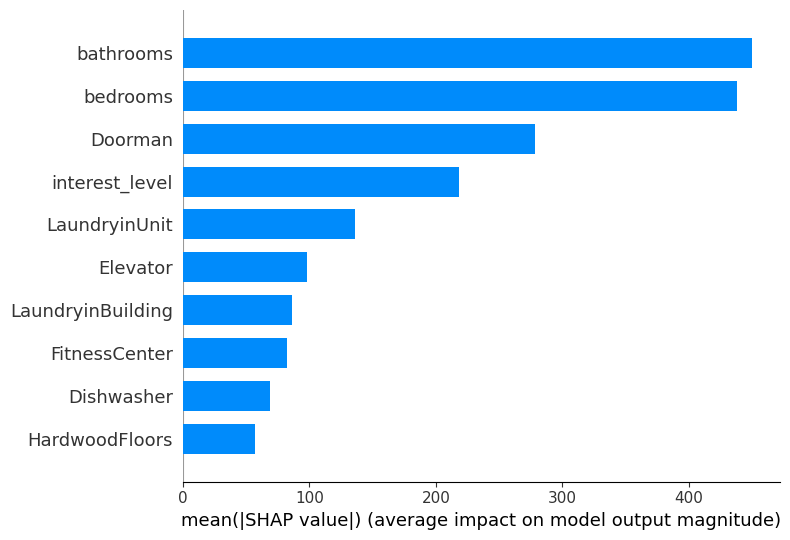

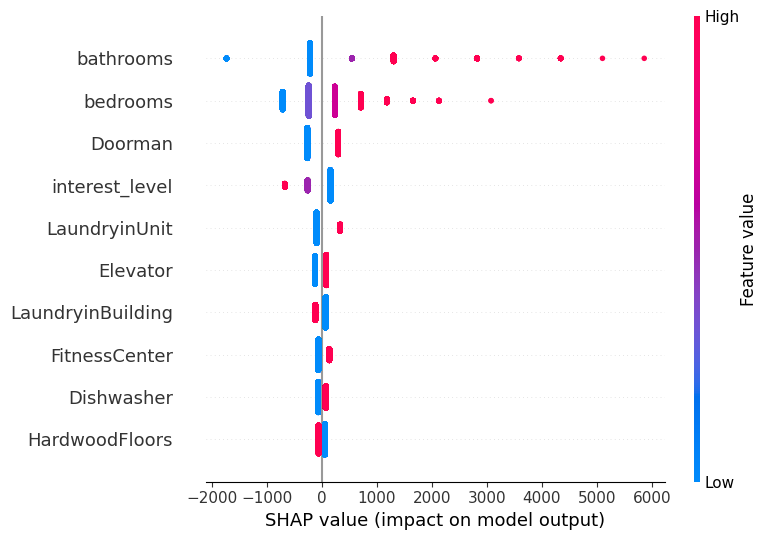

In [ ]:
explainer = shap.LinearExplainer(Lr_Lasso, X_train_)
shap_values = explainer.shap_values(X_train_)
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

out_shap = pd.DataFrame(
    mean_abs_shap.tolist(), 
    index=Lr_Lasso.feature_names_in_, 
    columns=["Top10_Shap"]
    ).sort_values(by="Top10_Shap", key=abs, ascending=False).reset_index(names="Features_Top10_Shap")

final_out_shap = final_out_simple.join(out_shap)
display(final_out_shap)

top_10_shap = out_shap.iloc[:10]["Features_Top10_Shap"]

shap.summary_plot(shap_values, X_train_, plot_type='bar', max_display=10) 
shap.summary_plot(shap_values, X_train_, max_display=10)

### 6.6 Compare the quality of these methods for different aspects — speed, metrics and stability.

In [ ]:
models = [(Lasso(alpha=alpha), "Lasso_with_all_features", [X_train_, X_valid_, X_test_]), 
          (Lasso(alpha=alpha), "Lasso_top_10", [X_train_[top_10], X_valid_[top_10], X_test_[top_10]]),
          (Lasso(alpha=alpha), "Lasso_top_10_simple", [X_train_[top_10_simple], X_valid_[top_10_simple], X_test_[top_10_simple]]),
          (Lasso(alpha=alpha), "Lasso_top_10_perm", [X_train_[top_10_perm], X_valid_[top_10_perm], X_test_[top_10_perm]]),
          (Lasso(alpha=alpha), "Lasso_top_10_shap", [X_train_[top_10_shap], X_valid_[top_10_shap], X_test_[top_10_shap]])
        ]

lr_results = fit_and_eval_models(
    models=models,
    y_train=y_train_,
    y_valid=y_valid_,
    y_test=y_test_
)

output_results(lr_results)

,model,train,valid,test,fit_time
0,Lasso_with_all_features,686.8074,683.1918,688.0368,0.3498
1,Lasso_top_10,690.1925,688.6493,690.3789,0.0600
2,Lasso_top_10_simple,690.1923,688.6491,690.3791,0.0568
3,Lasso_top_10_perm,689.3999,687.5555,689.4793,0.0601
4,Lasso_top_10_shap,690.1923,688.6491,690.3791,0.0565


,model,train,valid,test,fit_time
0,Lasso_with_all_features,994.7929,990.2794,1008.5757,0.3498
1,Lasso_top_10,1000.4210,998.2306,1013.9872,0.0600
2,Lasso_top_10_simple,1000.4210,998.2304,1013.9877,0.0568
3,Lasso_top_10_perm,999.6715,997.1410,1013.3791,0.0601
4,Lasso_top_10_shap,1000.4210,998.2304,1013.9877,0.0565


,model,train,valid,test,fit_time
0,Lasso_with_all_features,0.6056,0.6181,0.5889,0.3498
1,Lasso_top_10,0.6012,0.6119,0.5845,0.0600
2,Lasso_top_10_simple,0.6012,0.6119,0.5845,0.0568
3,Lasso_top_10_perm,0.6018,0.6128,0.5850,0.0601
4,Lasso_top_10_shap,0.6012,0.6119,0.5845,0.0565


# 7. Hyperparameter optimization

### 7.1 Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.

In [ ]:
def GridSearch(X, y, alpha_grid, l1_ratio_grid, scoring=r2_score, cv=5, random_state=42):
    iters, best_score, results = 0, 0, []
    best_params, best_model = None, None
    kf_cv = KFold(n_splits=cv, shuffle=False)
    
    for alpha in alpha_grid:
        for l1_ratio in l1_ratio_grid:
            iters += 1
            cv_scores = []
            
            for train, val in kf_cv.split(X):
                X_train, X_val = X.iloc[train], X.iloc[val]
                y_train, y_val = y.iloc[train], y.iloc[val]
                model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=random_state)
                model.fit(X_train, y_train)
                cv_scores.append(scoring(y_true=y_val, y_pred=model.predict(X_val)))
            
            mean_score = np.mean(cv_scores)
            
            results.append({
                'alpha': alpha,
                'l1_ratio': l1_ratio,
                'r2': mean_score,
                'cv_scores': cv_scores
            })
            
            if mean_score > best_score:
                best_score, best_model = mean_score, model
                best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}
    
    results_df = pd.DataFrame(results).sort_values('r2')
    
    return {
        'results': results_df,
        'best_params': best_params,
        'best_score': best_score,
        'best_model': best_model,
        'iters': iters
    }

In [ ]:

def RandomGridSearch(X, y, alpha_grid, l1_ratio_grid, scoring=r2_score, n_iter=50, cv=5, random_state=42):
    best_score, results = 0, []
    best_params, best_model = None, None
    kf_cv = KFold(n_splits=cv, shuffle=False)
    rng = np.random.RandomState(random_state)

    for _ in range(n_iter):
        cv_scores = []
        # uniform distribution - eq probability
        alpha = rng.uniform(alpha_grid[0], alpha_grid[1])
        l1_ratio = rng.uniform(l1_ratio_grid[0], l1_ratio_grid[1])
            
        for train, val in kf_cv.split(X):
            X_train, X_val = X.iloc[train], X.iloc[val]
            y_train, y_val = y.iloc[train], y.iloc[val]
            
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=random_state)
            model.fit(X_train, y_train)
            
            cv_scores.append(scoring(y_true=y_val, y_pred=model.predict(X_val)))
        
        mean_score = np.mean(cv_scores)
        
        results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'r2': mean_score,
            'cv_scores': cv_scores
        })
        
        if mean_score > best_score:
            best_score, best_model = mean_score, model
            best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}
    
    results_df = pd.DataFrame(results).sort_values('r2')
        
    return {
        'results': results_df,
        'best_params': best_params,
        'best_score': best_score,
        'best_model': best_model
    }

### 7.2 Find the best combination of model hyperparameters.

In [ ]:
alpha_grid = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
l1_ratio_grid = np.arange(0, 1, 0.1).tolist()

grid_result = GridSearch(X_train_, y_train_, alpha_grid, l1_ratio_grid, cv=5)
print("GridSearch")
print(f"Best parameters: {grid_result['best_params']}")
print(f"Best r2: {grid_result['best_score']:.6f}")
print(f"Iters: {grid_result['iters']}")

alpha_grid = (0.001, 10.0)
l1_ratio_grid = (0.1, 1.0)

random_result = RandomGridSearch(X_train_, y_train_, alpha_grid, l1_ratio_grid, n_iter=50, cv=5)
print("\nRandomGridSearch")
print(f"Best parameters: {random_result['best_params']}")
print(f"Best r2: {random_result['best_score']:.6f}")
print(f"Iters: 50")


KeyboardInterrupt: 

### 7.3 Fit the resulting model.

In [ ]:
alpha, l1_ratio = grid_result["best_params"]["alpha"], grid_result["best_params"]["l1_ratio"]

grid_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
grid_model.fit(X_train_, y_train_)

alpha, l1_ratio = random_result["best_params"]["alpha"], random_result["best_params"]["l1_ratio"]

random_grid_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
random_grid_model.fit(X_train_, y_train_)

,alpha,0.20682435846372868
,l1_ratio,0.9729188669457949
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


### 7.4 Import optuna and configure the same experiment with ElasticNet.

In [ ]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True) 
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0) 
    
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        random_state=42,
        max_iter=10000
    )
    model.fit(X_train_, y_train_)
    
    return model.score(X_train_, y_train_)

In [ ]:
def run_optuna_study(n_trials=10, timeout=None):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=42),
        study_name='elasticnet_optimization'
    )
    
    study.optimize(
        objective, 
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )
    
    return study

### 7.5 Estimate metrics and compare approaches.

In [ ]:
study = run_optuna_study(n_trials=10, timeout=600)

print("OptunaSearch")
print(f"Number of completed trials: {len(study.trials)}")
print(f"Best trial value (R2 score): {study.best_value:.6f}")
print(f"Best parameters: {study.best_params}")

alpha, l1_ratio = study.best_params["alpha"], study.best_params["l1_ratio"]

optuna_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
optuna_model.fit(X_train_, y_train_)

  0%|          | 0/10 [00:00<?, ?it/s]

OptunaSearch
Number of completed trials: 10
Best trial value (R2 score): 0.604364
Best parameters: {'alpha': 0.0008111941985431928, 'l1_ratio': 0.18340450985343382}


0.6056641

0.6056562

0.6056562

In [ ]:
display(f"optuna_model: 0.{int(round(optuna_model.score(X_train_, y_train_), 6) * 10**6):_}")
display(f"grid_model: 0.{int(round(grid_model.score(X_train_, y_train_), 6) * 10**6):_}")
display(f"random_grid_model: 0.{int(round(random_grid_model.score(X_train_, y_train_), 6) * 10**6):_}")

'optuna_model: 0.605_664'

'grid_model: 0.605_656'

'random_grid_model: 0.605_650'

### 7.6 Run optuna on one of the cross-validation schemes.

In [ ]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)  # log-uniform
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)  # uniform
    
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        random_state=42,
        max_iter=10000
    )
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=kfold, scoring='r2', n_jobs=-1
    )
    
    return cv_scores.mean()

In [ ]:
study = run_optuna_study(n_trials=10, timeout=600)  

print("OptunaCVSearch")
print(f"Number of completed trials: {len(study.trials)}")
print(f"Best trial value (R2 score): {study.best_value:.6f}")
print(f"Best parameters: {study.best_params}")


alpha, l1_ratio = study.best_params["alpha"], study.best_params["l1_ratio"]

optuna_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
optuna_model.fit(X_train_, y_train_)

optuna_model.score(X_train_, y_train_)
display(f"optuna_model: 0.{int(round(optuna_model.score(X_train_, y_train_), 6) * 10**6):_}")

  0%|          | 0/10 [00:00<?, ?it/s]

OptunaCVSearch
Number of completed trials: 10
Best trial value (R2 score): 0.604364
Best parameters: {'alpha': 0.0008111941985431928, 'l1_ratio': 0.18340450985343382}


'optuna_model: 0.605_664'